In [1]:
%pip install opencv-python
%pip install -r requirements-min.txt

import os
import warnings
import torch
from transformers import AutoConfig, AutoImageProcessor, AutoProcessor
try:
    from transformers import AutoModelForVision2Seq
except ImportError:
    # Older/newer transformers versions may expose this class under a different name.
    from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq
from huggingface_hub import snapshot_download

import time
import numpy as np
import cv2
import textwrap
from PIL import Image, ImageDraw, ImageFont
import enum

# If your Hugging Face token isn't already configured (~/.cache/huggingface/token,
# or the HF_TOKEN env var from your shell), uncomment one of these instead of
# hardcoding a token in the notebook:
#   from huggingface_hub import login; login()          # interactive prompt
#   os.environ["HF_TOKEN"] = getpass.getpass("HF token: ")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/home/glows/embodied-CoT-v2/.venv-sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Define some utils.

def split_reasoning(text, tags):
    new_parts = {None: text}

    for tag in tags:
        parts = new_parts
        new_parts = dict()

        for k, v in parts.items():
            if tag in v:
                s = v.split(tag)
                new_parts[k] = s[0]
                new_parts[tag] = s[1]
                # print(tag, s)
            else:
                new_parts[k] = v

    return new_parts

class CotTag(enum.Enum):
    TASK = "TASK:"
    PLAN = "PLAN:"
    VISIBLE_OBJECTS = "VISIBLE OBJECTS:"
    SUBTASK_REASONING = "SUBTASK REASONING:"
    SUBTASK = "SUBTASK:"
    MOVE_REASONING = "MOVE REASONING:"
    MOVE = "MOVE:"
    GRIPPER_POSITION = "GRIPPER POSITION:"
    ACTION = "ACTION:"


def get_cot_tags_list():
    return [
        CotTag.TASK.value,
        CotTag.PLAN.value,
        CotTag.VISIBLE_OBJECTS.value,
        CotTag.SUBTASK_REASONING.value,
        CotTag.SUBTASK.value,
        CotTag.MOVE_REASONING.value,
        CotTag.MOVE.value,
        CotTag.GRIPPER_POSITION.value,
        CotTag.ACTION.value,
    ]

def name_to_random_color(name):
    return [(hash(name) // (256**i)) % 256 for i in range(3)]




def draw_gripper(img, pos_list, img_size=(640, 480)):
    for i, pos in enumerate(reversed(pos_list)):
        pos = resize_pos(pos, img_size)
        scale = 255 - int(255 * i / len(pos_list))
        cv2.circle(img, pos, 6, (0, 0, 0), -1)
        cv2.circle(img, pos, 5, (scale, scale, 255), -1)

def get_metadata(reasoning):
    metadata = {"gripper": [[0, 0]], "bboxes": dict()}

    if f" {CotTag.GRIPPER_POSITION.value}" in reasoning:
        gripper_pos = reasoning[f" {CotTag.GRIPPER_POSITION.value}"]
        gripper_pos = gripper_pos.split("[")[-1]
        gripper_pos = gripper_pos.split("]")[0]
        gripper_pos = [int(x) for x in gripper_pos.split(",")]
        gripper_pos = [(gripper_pos[2 * i], gripper_pos[2 * i + 1]) for i in range(len(gripper_pos) // 2)]
        metadata["gripper"] = gripper_pos

    if f" {CotTag.VISIBLE_OBJECTS.value}" in reasoning:
        for sample in reasoning[f" {CotTag.VISIBLE_OBJECTS.value}"].split("]"):
            obj = sample.split("[")[0]
            if obj == "":
                continue
            coords = [int(n) for n in sample.split("[")[-1].split(",")]
            metadata["bboxes"][obj] = coords

    return metadata

def resize_pos(pos, img_size):
    return [(x * size) // 256 for x, size in zip(pos, img_size)]

def draw_bboxes(img, bboxes, img_size=(640, 480)):
    for name, bbox in bboxes.items():
        show_name = name
        # show_name = f'{name}; {str(bbox)}'

        cv2.rectangle(
            img,
            resize_pos((bbox[0], bbox[1]), img_size),
            resize_pos((bbox[2], bbox[3]), img_size),
            name_to_random_color(name),
            1,
        )
        cv2.putText(
            img,
            show_name,
            resize_pos((bbox[0], bbox[1] + 6), img_size),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

In [3]:
# Auto-select runtime settings to avoid CUDA/FlashAttention crashes on unsupported setups.
if torch.cuda.is_available():
    device = "cuda:0"
    model_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    attn_impl = "flash_attention_2"
else:
    device = "cpu"
    model_dtype = torch.float32
    attn_impl = "eager"

# Speed up Hugging Face downloads and silence a harmless deprecation warning.
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
warnings.filterwarnings(
    "ignore",
    message="`resume_download` is deprecated and will be removed in version 1.0.0.*",
    category=FutureWarning,
    module="huggingface_hub.file_download",
)

repo_id = "Embodied-CoT/ecot-openvla-7b-bridge"
local_ckpt = snapshot_download(
    repo_id=repo_id,
    local_dir="./.hf_models/ecot-openvla-7b-bridge",
    local_dir_use_symlinks=False,
    max_workers=16,
    etag_timeout=30,
    force_download=False,
    local_files_only=False,
)

# Load Processor & VLA from the local snapshot path (fast on repeated runs).
processor = AutoProcessor.from_pretrained(local_ckpt, trust_remote_code=True)

try:
    vla = AutoModelForVision2Seq.from_pretrained(
        local_ckpt,
        attn_implementation=attn_impl,
        torch_dtype=model_dtype,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
    ).to(device)
except Exception as err:
    # Fall back to eager attention if FlashAttention is unavailable.
    if attn_impl == "flash_attention_2":
        print(f"Falling back to eager attention because FlashAttention is not available: {err}")
        attn_impl = "eager"
        vla = AutoModelForVision2Seq.from_pretrained(
            local_ckpt,
            attn_implementation=attn_impl,
            torch_dtype=model_dtype,
            low_cpu_mem_usage=True,
            trust_remote_code=True,
        ).to(device)
    else:
        raise

print(f"Using device={device}, dtype={model_dtype}, attn={attn_impl}")
print(f"Model files ready at: {local_ckpt}")

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]/home/glows/embodied-CoT-v2/.venv-sim/lib/python3.11/site-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(
Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 1028.74it/s]


Falling back to eager attention because FlashAttention is not available: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package flash_attn seems to be not installed. Please refer to the documentation of https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2 to install Flash Attention 2.


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  5.32it/s]


Using device=cuda:0, dtype=torch.bfloat16, attn=eager
Model files ready at: /home/glows/embodied-CoT-v2/.hf_models/ecot-openvla-7b-bridge


In [4]:
SYSTEM_PROMPT = (
    "A chat between a curious user and an artificial intelligence assistant. "
    "The assistant gives helpful, detailed, and polite answers to the user's questions."
)

def get_openvla_prompt(instruction: str) -> str:
    return f"{SYSTEM_PROMPT} USER: What action should the robot take to {instruction.lower()}? ASSISTANT: TASK:"

INSTRUCTION = "place the watermelon on the towel"
prompt = get_openvla_prompt(INSTRUCTION)
image = Image.open("./test_obs.png")
print(prompt.replace(". ", ".\n"))

A chat between a curious user and an artificial intelligence assistant.
The assistant gives helpful, detailed, and polite answers to the user's questions.
USER: What action should the robot take to place the watermelon on the towel? ASSISTANT: TASK:


In [5]:
# Use the same dtype selected during model load.
inputs = processor(prompt, image).to(device, dtype=model_dtype)
# inputs["input_ids"] = inputs["input_ids"][:, 1:]

# Run OpenVLA inference
start_time = time.time()

torch.manual_seed(0)
action, generated_ids = vla.predict_action(**inputs, unnorm_key="bridge_orig", do_sample=False, max_new_tokens=1024)
generated_text = processor.batch_decode(generated_ids)[0]
print(f"Time: {time.time() - start_time:.4f} || Action: {action}")

Time: 12.1827 || Action: [ 0.01321167 -0.03668522  0.00027841 -0.0205739  -0.02891492 -0.08065662
  0.        ]


In [6]:
tags = [f" {tag}" for tag in get_cot_tags_list()]
reasoning = split_reasoning(generated_text, tags)
text = [tag + reasoning[tag] for tag in [' TASK:',' PLAN:',' SUBTASK REASONING:',' SUBTASK:',
                                        ' MOVE REASONING:',' MOVE:', ' VISIBLE OBJECTS:', ' GRIPPER POSITION:'] if tag in reasoning]
metadata = get_metadata(reasoning)
bboxes = {}
for k, v in metadata["bboxes"].items():
    if k[0] == ",":
        k = k[1:]
    bboxes[k.lstrip().rstrip()] = v

caption = ""
for t in text:
    wrapper = textwrap.TextWrapper(width=80, replace_whitespace=False) 
    word_list = wrapper.wrap(text=t) 
    caption_new = ''
    for ii in word_list[:-1]:
        caption_new = caption_new + ii + '\n      '
    caption_new += word_list[-1]

    caption += caption_new.lstrip() + "\n\n"

base = Image.fromarray(np.ones((480, 640, 3), dtype=np.uint8) * 255)
draw = ImageDraw.Draw(base)
font = ImageFont.load_default(size=14) # big text
color = (0,0,0) # RGB
draw.text((30, 30), caption, color, font=font)

img_arr = np.array(image)
draw_gripper(img_arr, metadata["gripper"])
draw_bboxes(img_arr, bboxes)

text_arr = np.array(base)

reasoning_img = Image.fromarray(np.concatenate([img_arr, text_arr], axis=1))

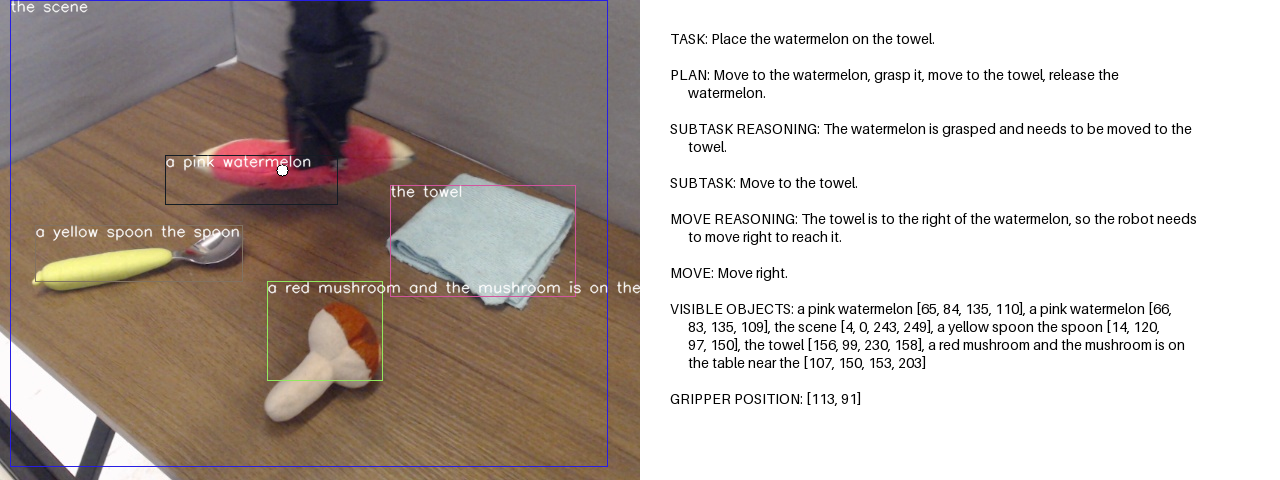

In [7]:
reasoning_img

## Closed-loop rollout in a real physics simulator (SimplerEnv / ManiSkill2)

The cells above run the model on one static image. The cells below drive it in an
actual closed control loop against [SimplerEnv](https://github.com/simpler-env/SimplerEnv)
(WidowX + Bridge tasks, built on ManiSkill2/SAPIEN): the model sees a rendered frame,
predicts an action, the action is applied to the simulated robot, physics steps
forward, and the model sees the *new* frame — repeat.

**Requirements:** Linux + an NVIDIA GPU with a working Vulkan driver. SAPIEN 2.2.2
(what this simulator needs) only ships wheels for Python ≤3.11 and predates NumPy
2.0's C-API change, so it can't share this notebook's main (Python 3.12, NumPy 2.x)
environment — the cells below provision and talk to a second, isolated environment
(`.venv-sim`) over a local socket instead. See `scripts/sim/setup_sim_env.sh` for
what that installs and why.

In [8]:
import subprocess
from pathlib import Path

# One-time, idempotent: downloads a standalone Python 3.11, creates .venv-sim,
# and installs SimplerEnv/ManiSkill2_real2sim/sapien==2.2.2 into it. Safe to
# re-run — every step is skipped if already done. Takes a few minutes the
# first time (mostly cloning ManiSkill2_real2sim's bundled assets), instant after.
sim_python = Path("./.venv-sim/bin/python")
if not sim_python.exists():
    print("Sim environment not found — provisioning it now (first run only, a few minutes)...")
    subprocess.run(["bash", "scripts/sim/setup_sim_env.sh"], check=True)
else:
    print(f"Sim environment already set up at {sim_python}")

Sim environment already set up at .venv-sim/bin/python


In [9]:
import sys
sys.path.insert(0, ".")
from scripts.sim.sim_bridge_client import SimplerEnvBridge

# Other options: widowx_spoon_on_towel, widowx_carrot_on_plate, widowx_stack_cube
SIM_TASK = "widowx_put_eggplant_in_basket"
MAX_STEPS = 20  # ~7s of sim time at the tasks' 3 Hz control rate; raise to let it run longer


def make_reasoning_frame(obs_image, generated_text):
    """Same reasoning + gripper/bbox overlay as the single-shot cell above, factored
    out so the rollout loop below can build one per step."""
    tags = [f" {tag}" for tag in get_cot_tags_list()]
    reasoning = split_reasoning(generated_text, tags)
    text = [tag + reasoning[tag] for tag in [' TASK:', ' PLAN:', ' SUBTASK REASONING:', ' SUBTASK:',
                                              ' MOVE REASONING:', ' MOVE:', ' VISIBLE OBJECTS:', ' GRIPPER POSITION:'] if tag in reasoning]
    metadata = get_metadata(reasoning)
    bboxes = {}
    for k, v in metadata["bboxes"].items():
        if k[0] == ",":
            k = k[1:]
        bboxes[k.lstrip().rstrip()] = v

    caption = ""
    for t in text:
        wrapper = textwrap.TextWrapper(width=80, replace_whitespace=False)
        word_list = wrapper.wrap(text=t)
        caption_new = ''
        for ii in word_list[:-1]:
            caption_new = caption_new + ii + '\n      '
        caption_new += word_list[-1] if word_list else ''
        caption += caption_new.lstrip() + "\n\n"

    base = Image.fromarray(np.ones((480, 640, 3), dtype=np.uint8) * 255)
    draw = ImageDraw.Draw(base)
    font = ImageFont.load_default(size=14)
    draw.text((30, 30), caption, (0, 0, 0), font=font)

    img_arr = np.array(obs_image)
    draw_gripper(img_arr, metadata["gripper"])
    draw_bboxes(img_arr, bboxes)

    return Image.fromarray(np.concatenate([img_arr, np.array(base)], axis=1))


frames = []
with SimplerEnvBridge(task=SIM_TASK) as sim:
    obs_image, instruction = sim.reset()
    print(f"Task: {SIM_TASK!r}  |  Instruction: {instruction!r}")

    for t in range(MAX_STEPS):
        step_prompt = get_openvla_prompt(instruction)
        step_inputs = processor(step_prompt, obs_image).to(device, dtype=model_dtype)
        step_action, step_generated_ids = vla.predict_action(
            **step_inputs, unnorm_key="bridge_orig", do_sample=False, max_new_tokens=1024
        )
        step_generated_text = processor.batch_decode(step_generated_ids)[0]

        frames.append(make_reasoning_frame(obs_image, step_generated_text))

        obs_image, reward, terminated, truncated, success, info = sim.step(step_action)
        print(f"step {t:02d}  action={np.round(step_action, 3)}  success={success}")
        if terminated or truncated:
            print(f"Episode ended at step {t} (success={success})")
            break

print(f"Collected {len(frames)} frames.")

Task: 'widowx_put_eggplant_in_basket'  |  Instruction: 'put eggplant into yellow basket'
step 00  action=[-0.001 -0.001 -0.008 -0.003  0.023 -0.011  0.996]  success=False
step 01  action=[-0.002 -0.    -0.008 -0.     0.023  0.014  0.996]  success=False
step 02  action=[-0.002 -0.    -0.008 -0.     0.023  0.024  0.996]  success=False
step 03  action=[-0.002 -0.001 -0.006  0.     0.021 -0.008  0.996]  success=False
step 04  action=[-0.002 -0.    -0.008 -0.     0.023  0.014  0.996]  success=False
step 05  action=[-0.002 -0.001 -0.007 -0.005  0.021  0.026  0.996]  success=False
step 06  action=[-0.002 -0.017 -0.011 -0.017 -0.025  0.081  0.996]  success=False
step 07  action=[-0.002 -0.    -0.008  0.004  0.023  0.016  0.996]  success=False
step 08  action=[ 0.001 -0.    -0.009  0.009  0.021  0.006  0.996]  success=False
step 09  action=[ 0.001 -0.    -0.008  0.009  0.021  0.027  0.996]  success=False
step 10  action=[-0.004 -0.001 -0.01   0.005  0.032  0.013  0.996]  success=False
step 11  